# Assignment 15 — Exercise Quality Score Regressor

**Pipeline:**  
Filter ugly recordings (A14 model) → Cut start/stop (A12 model) → Augment → Feature engineer → Fixed c frames → Train Dense / CNN / RNN regressors → Evaluate with MAE, MSE, Bland-Altman, correlation → MLflow

## Imports

In [1]:
import os, glob, sys, random, warnings, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
import mlflow
import mlflow.pytorch
import dagshub
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

sys.path.append('../../scripts')
import ml_utils as mlutils


## Helpers & Model Classes

In [2]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def get_feat_cols(columns):
    return [c for c in columns if '_3d_' in c]


class ActivityGatekeeper(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bidirectional = config.get('bidirectional', False)
        mult    = 2 if self.bidirectional else 1
        rnn_cls = nn.GRU if config.get('rnn_type','LSTM') == 'GRU' else nn.LSTM
        self.rnn = rnn_cls(
            config['input_size'], config['hidden_size'], config['num_layers'],
            batch_first=True,
            dropout=config['dropout'] if config['num_layers'] > 1 else 0,
            bidirectional=self.bidirectional,
        )
        act = config.get('activation', 'identity')
        self.act = nn.ReLU() if act=='relu' else (nn.Tanh() if act=='tanh' else nn.Identity())
        self.fc  = nn.Linear(config['hidden_size'] * mult, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(self.act(out[:, -1, :]))
    
def to_fixed_length(arr, c=10):
    n=len(arr)
    if n==c: return arr
    if n<c:
        return np.vstack([arr, np.zeros((c-n,arr.shape[1]),'float32')])
    idx=np.round(np.linspace(0,n-1,c)).astype(int)
    return arr[idx]


## MLflow & Device Setup

In [3]:
dagshub.init(repo_owner='SamuelFredricBerg', repo_name='4dt907', mlflow=True)

PROJECT   = 'Score_Regressor_A15_V2'
utils     = mlutils.mlutils(PROJECT)
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PLOTS_DIR = 'plots_a15'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'Device: {device}')


Accessing as Soppa22

Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

Device: cpu


## Load Ground-Truth Scores

Score range: 0.000 – 4.000
Mean: 2.000  Std: 0.7207


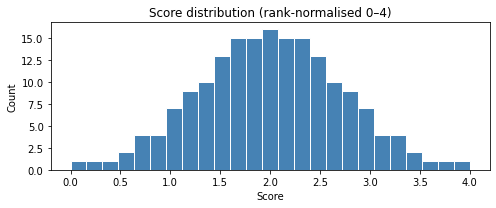

In [4]:
SCORE_MAX = 4.0

from scipy.stats import norm

scores_df = pd.read_csv('../../data/scores_a15.csv')
scores_df.columns = ['filename', 'score']

# Sort by score, assign ranks, map to normal distribution
scores_df = scores_df.sort_values('score').reset_index(drop=True)
n = len(scores_df)

# Map rank to quantile, then to normal distribution scaled to 0–4
quantiles = (scores_df.index + 0.5) / n          # evenly spaced quantiles 0–1
scores_df['score'] = norm.ppf(quantiles)           # inverse normal → mean=0 std=1
scores_df['score'] = (scores_df['score'] - scores_df['score'].min()) / \
                     (scores_df['score'].max() - scores_df['score'].min()) * SCORE_MAX

scores_map = dict(zip(scores_df['filename'].str.replace('_kinect',''), scores_df['score']))

print(f'Score range: {scores_df.score.min():.3f} – {scores_df.score.max():.3f}')
print(f'Mean: {scores_df.score.mean():.3f}  Std: {scores_df.score.std():.4f}')
plt.figure(figsize=(7,3))
plt.hist(scores_df['score'], bins=25, color='steelblue', edgecolor='white')
plt.xlabel('Score'); plt.ylabel('Count'); plt.title('Score distribution (rank-normalised 0–4)')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR,'score_dist.png'),dpi=120); plt.show()


In [5]:
KEY_DIST_PAIRS = [
    ('left_shoulder','right_shoulder'),('left_elbow','right_elbow'),
    ('left_wrist','right_wrist'),('left_hip','right_hip'),
    ('left_knee','right_knee'),('left_ankle','right_ankle'),
    ('left_shoulder','left_elbow'),('left_elbow','left_wrist'),
    ('right_shoulder','right_elbow'),('right_elbow','right_wrist'),
    ('left_hip','left_knee'),('left_knee','left_ankle'),
    ('right_hip','right_knee'),('right_knee','right_ankle'),
    ('left_shoulder','left_hip'),('right_shoulder','right_hip'),
]
KEY_ANGLE_TRIPLES = [
    ('left_shoulder','left_elbow','left_wrist'),
    ('right_shoulder','right_elbow','right_wrist'),
    ('left_hip','left_knee','left_ankle'),
    ('right_hip','right_knee','right_ankle'),
    ('left_elbow','left_shoulder','left_hip'),
    ('right_elbow','right_shoulder','right_hip'),
]

def _pos(arr, fc, joint):
    idxs=[]
    for ax in ['x','y','z']:
        col=f'{joint}_3d_{ax}'
        if col not in fc: return None
        idxs.append(fc.index(col))
    return arr[:,idxs]

def add_features(arr, fc):
    extras=[]
    pls=_pos(arr,fc,'left_shoulder'); prs=_pos(arr,fc,'right_shoulder')
    scale = np.linalg.norm(prs-pls,axis=1,keepdims=True).mean()+1e-8 if pls is not None and prs is not None else 1.0
    for j1,j2 in KEY_DIST_PAIRS:
        p1,p2=_pos(arr,fc,j1),_pos(arr,fc,j2)
        if p1 is not None and p2 is not None:
            extras.append(np.linalg.norm(p2-p1,axis=1,keepdims=True)/scale)
    for ja,jv,jb in KEY_ANGLE_TRIPLES:
        pa,pv,pb=_pos(arr,fc,ja),_pos(arr,fc,jv),_pos(arr,fc,jb)
        if pa is not None and pv is not None and pb is not None:
            va,vb=pa-pv,pb-pv
            cos=(np.sum(va*vb,axis=1)/(np.linalg.norm(va,axis=1)*np.linalg.norm(vb,axis=1)+1e-8))
            extras.append(cos.reshape(-1,1))
    return np.hstack([arr]+extras).astype('float32') if extras else arr


## Load Filter & Cut Models

In [6]:
# ── A12 start/stop model ─────────────────────────────────────────────────────
SS_CONFIG = {
    'rnn_type':'LSTM','bidirectional':False,'hidden_size':128,'num_layers':2,
    'seq_length':5,'input_size':39,'dropout':0.1,'activation':'identity','use_scaling':False,
}
ss_model = ActivityGatekeeper(SS_CONFIG).to(device)
ss_model.load_state_dict(torch.load('best_start_stop_model_prod.pth', map_location=device, weights_only=True))
ss_model.eval()
print('Start/stop model loaded')


# ── Good/Bad classifier from DagShub ─────────────────────────────────────────
with open('goodbad_config.json') as f:
    gb_cfg = json.load(f)

gb_type     = gb_cfg.get('model_type', 'dense')
GB_C        = 10
GB_N_FEAT   = 61   # 39 coords + 16 distances + 6 angles

class _GBDense(nn.Module):
    def __init__(self):
        super().__init__()
        h1 = int(gb_cfg['h1']); h2 = int(gb_cfg['h2'])
        dr = float(gb_cfg['dropout'])
        idim = GB_C * GB_N_FEAT
        self.net = nn.Sequential(
            nn.Linear(idim,h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dr),
            nn.Linear(h1,h2), nn.ReLU(), nn.Linear(h2,1))
    def forward(self,x): return self.net(x)

class _GBCNN(nn.Module):
    def __init__(self):
        super().__init__()
        nf = int(gb_cfg['n_filters']); ks = int(gb_cfg['kernel_size'])
        ps = int(gb_cfg['pool_size']); fh = int(gb_cfg['fc_h'])
        dr = float(gb_cfg['dropout'])
        co = nf * (GB_C // ps)
        self.conv = nn.Sequential(nn.Conv1d(GB_N_FEAT,nf,ks,padding=ks//2),nn.ReLU(),nn.MaxPool1d(ps))
        self.fc   = nn.Sequential(nn.Flatten(),nn.Dropout(dr),nn.Linear(co,fh),nn.ReLU(),nn.Linear(fh,1))
    def forward(self,x): return self.fc(self.conv(x.permute(0,2,1)))

gb_model = (_GBDense() if gb_type == 'dense' else _GBCNN()).to(device)
gb_model.load_state_dict(torch.load('best_goodbad_model_prod.pth', map_location=device, weights_only=True))
gb_model.eval()

gb_scaler = None
if os.path.exists('scaler_goodbad_prod.joblib'):
    gb_scaler = joblib.load('scaler_goodbad_prod.joblib')

print(f'Good/Bad classifier loaded: type={gb_type}  scaler={"yes" if gb_scaler else "no"}')


Start/stop model loaded
Good/Bad classifier loaded: type=cnn  scaler=yes


## Filter Ugly & Cut Sequences

In [7]:
DATA_DIR = '../../data/kinect_good_preprocessed_not_cut_A11_mediapipe'
C        = 10
MIN_SEQ  = C


def cut_with_model(df, model, config, device, min_length=MIN_SEQ):
    feat_cols = get_feat_cols(df.columns)
    X = df[feat_cols].values.astype('float32')
    seq_len = config['seq_length']
    preds   = [0] * (seq_len - 1)
    with torch.no_grad():
        for i in range(len(df) - seq_len + 1):
            w    = torch.tensor(X[i:i+seq_len]).unsqueeze(0).to(device)
            prob = torch.sigmoid(model(w)).item()
            preds.append(1 if prob >= 0.5 else 0)
    active = np.where(np.array(preds)==1)[0]
    if len(active) == 0: return None
    cut = df.iloc[active[0]:active[-1]+1].reset_index(drop=True)
    return cut if len(cut) >= min_length else None


def is_good_squat(arr, feat_cols, model, scaler, model_type, c=GB_C):
    enriched = add_features(arr, feat_cols)
    fixed    = to_fixed_length(enriched, c)
    X = fixed.flatten()[None,:] if model_type == 'dense' else fixed[None,:,:]
    if scaler is not None:
        X = scaler.transform(X.reshape(1,-1)).reshape(X.shape)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(torch.tensor(X, dtype=torch.float32, device=device))).item()
    return prob >= 0.5


all_csv = sorted(glob.glob(os.path.join(DATA_DIR,'*.csv')))
print(f'Found {len(all_csv)} CSV files')

raw_sequences = []
skipped_cut, skipped_score, skipped_goodbad = [], [], []

for f in tqdm(all_csv, desc='Cut+Filter'):
    key = os.path.splitext(os.path.basename(f))[0].replace('_kinect','')
    if key not in scores_map:
        skipped_score.append(key); continue

    df     = pd.read_csv(f)
    cut_df = cut_with_model(df, ss_model, SS_CONFIG, device)
    if cut_df is None:
        skipped_cut.append(key); continue

    feat_cols = get_feat_cols(cut_df.columns)
    feat_arr  = cut_df[feat_cols].values.astype('float32')

    if not is_good_squat(feat_arr, feat_cols, gb_model, gb_scaler, gb_type):
        skipped_goodbad.append(key); continue

    raw_sequences.append((feat_arr, scores_map[key], f, feat_cols))

print(f'Kept : {len(raw_sequences)}')
print(f'Skipped — no score: {len(skipped_score)}  bad cut: {len(skipped_cut)}  not squat: {len(skipped_goodbad)}')
FEAT_COLS = raw_sequences[0][3]

Found 180 CSV files


Cut+Filter: 100%|██████████| 180/180 [00:18<00:00,  9.65it/s]

Kept : 131
Skipped — no score: 0  bad cut: 0  not squat: 49


## Augmentation

In [8]:
LEFT_RIGHT_PAIRS = [
    ('left_shoulder','right_shoulder'),('left_elbow','right_elbow'),
    ('left_wrist','right_wrist'),('left_hip','right_hip'),
    ('left_knee','right_knee'),('left_ankle','right_ankle'),
]

def _col_idx(fc, joint, ax):
    try: return fc.index(f'{joint}_3d_{ax}')
    except ValueError: return -1

def aug_mirror(arr, fc):
    a = arr.copy()
    xi = [i for i,c in enumerate(fc) if c.endswith('_3d_x')]
    a[:,xi] = 1.0 - a[:,xi]
    for l,r in LEFT_RIGHT_PAIRS:
        for ax in ['x','y','z']:
            li,ri = _col_idx(fc,l,ax),_col_idx(fc,r,ax)
            if li==-1 or ri==-1: continue
            a[:,li],a[:,ri] = arr[:,ri].copy(),arr[:,li].copy()
            if ax=='x': a[:,li]=1-a[:,li]; a[:,ri]=1-a[:,ri]
    return a

def aug_rotate_y(arr, fc, deg):
    a=arr.copy(); t=np.radians(deg); c,s=np.cos(t),np.sin(t)
    xi=[i for i,col in enumerate(fc) if col.endswith('_3d_x')]
    zi=[i for i,col in enumerate(fc) if col.endswith('_3d_z')]
    for x,z in zip(xi,zi):
        xv,zv=arr[:,x].copy(),arr[:,z].copy()
        a[:,x]=c*xv+s*zv; a[:,z]=-s*xv+c*zv
    return a

def aug_scale(arr, fc, sx=1.0, sy=1.0, sz=1.0):
    a=arr.copy()
    for i,col in enumerate(fc):
        if col.endswith('_3d_x'): a[:,i]*=sx
        elif col.endswith('_3d_y'): a[:,i]*=sy
        elif col.endswith('_3d_z'): a[:,i]*=sz
    return a

def aug_noise(arr, sigma=0.005):
    return arr + np.random.normal(0,sigma,arr.shape).astype('float32')

def generate_variants(arr, fc):
    m = aug_mirror(arr,fc)
    return [
        arr, m,
        aug_rotate_y(arr,fc,-10), aug_rotate_y(arr,fc,-5),
        aug_rotate_y(arr,fc,5),  aug_rotate_y(arr,fc,10),
        aug_rotate_y(m,fc,-5),   aug_rotate_y(m,fc,5),
        aug_scale(arr,fc,0.95,0.95,0.95), aug_scale(arr,fc,1.05,1.05,1.05),
        aug_scale(m,fc,0.95,0.95,0.95),   aug_scale(m,fc,1.05,1.05,1.05),
        aug_noise(arr,0.005), aug_noise(arr,0.010), aug_noise(m,0.005),
    ]

augmented_pool = []
for gid,(arr,score,fpath,fc) in enumerate(tqdm(raw_sequences,desc='Augmenting')):
    for v in generate_variants(arr,fc):
        augmented_pool.append((v, score, gid))

N_VARIANTS_PER = len(generate_variants(raw_sequences[0][0], FEAT_COLS))
orig_indices   = np.arange(0, len(augmented_pool), N_VARIANTS_PER)
print(f'Pool: {len(augmented_pool)} sequences ({N_VARIANTS_PER} variants each)')


Augmenting: 100%|██████████| 131/131 [00:00<00:00, 730.37it/s]

Pool: 1965 sequences (15 variants each)


## Fixed-Size Sequences (c frames)

In [9]:
X_seq, y_all, grp_all = [], [], []
for arr,score,gid in tqdm(augmented_pool,desc='Building sequences'):
    enriched = add_features(arr, FEAT_COLS)
    fixed    = to_fixed_length(enriched, C)
    X_seq.append(fixed); y_all.append(score); grp_all.append(gid)

X_seq   = np.array(X_seq,  dtype='float32')
X_flat  = X_seq.reshape(len(X_seq),-1)
y_all   = np.array(y_all,  dtype='float32')
grp_all = np.array(grp_all)

N_FEAT      = X_seq.shape[2]
INPUT_DENSE = X_flat.shape[1]
print(f'Shape: {X_seq.shape}  Dense input: {INPUT_DENSE}  Score range: {y_all.min():.2f}–{y_all.max():.2f}')


Building sequences: 100%|██████████| 1965/1965 [00:00<00:00, 2220.53it/s]

Shape: (1965, 10, 61)  Dense input: 610  Score range: 0.00–3.49


## Model Definitions

In [10]:
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)


class ADense(nn.Module):
    def __init__(self, input_dim, h1, h2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1,h2), nn.ReLU(), nn.Linear(h2,1)
        )
        for m in self.modules():
            if isinstance(m,nn.Linear): init.xavier_uniform_(m.weight)
    def forward(self,x): return self.net(x)


class ACNN(nn.Module):
    def __init__(self, n_feat, seq_len=C, n_filters=8, kernel_size=3, pool_size=2, fc_h=16, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat,n_filters,kernel_size,padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool_size))
        co = n_filters*(seq_len//pool_size)
        self.fc = nn.Sequential(nn.Flatten(),nn.Dropout(dropout),nn.Linear(co,fc_h),nn.ReLU(),nn.Linear(fc_h,1))
        for m in self.modules():
            if isinstance(m,nn.Linear): init.xavier_uniform_(m.weight)
            elif isinstance(m,nn.Conv1d): init.kaiming_normal_(m.weight)
    def forward(self,x): return self.fc(self.conv(x.permute(0,2,1)))


class ARNN(nn.Module):
    def __init__(self, n_feat, hidden=32, num_layers=1, rnn_type='GRU', dropout=0.0):
        super().__init__()
        rnn_cls  = nn.GRU if rnn_type=='GRU' else nn.LSTM
        self.rnn = rnn_cls(n_feat,hidden,num_layers,batch_first=True,
                           dropout=dropout if num_layers>1 else 0)
        self.fc  = nn.Linear(hidden,1)
        init.xavier_uniform_(self.fc.weight)
    def forward(self,x):
        out,_ = self.rnn(x); return self.fc(out[:,-1,:])


_h1 = max(8, int(9000/INPUT_DENSE))
_h2 = max(4, _h1//2)
_d  = ADense(INPUT_DENSE,_h1,_h2)
_c  = ACNN(N_FEAT,C)
_r  = ARNN(N_FEAT)
print(f'ADense {count_params(_d):,}  ACNN {count_params(_c):,}  ARNN {count_params(_r):,}')


ADense 8,695  ACNN 2,145  ARNN 9,153


## Training Utilities & Plots

In [11]:
from contextlib import nullcontext

class ScoreDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss=0.0; preds=[]; targets=[]
    ctx = nullcontext() if train else torch.no_grad()
    with ctx:
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            if train: optimizer.zero_grad()
            out=model(xb); loss=criterion(out,yb)
            if train: loss.backward(); optimizer.step()
            total_loss+=loss.item()
            preds.extend(out.detach().cpu().numpy().flatten())
            targets.extend(yb.cpu().numpy().flatten())
    p=np.array(preds); t=np.array(targets)
    return total_loss/len(loader), float(np.mean((p-t)**2)), float(np.mean(np.abs(p-t)))


def evaluate(model, loader, device):
    model.eval(); preds=[]; targets=[]
    with torch.no_grad():
        for xb,yb in loader:
            preds.extend(model(xb.to(device)).cpu().numpy().flatten())
            targets.extend(yb.numpy().flatten())
    p=np.array(preds); t=np.array(targets)
    mse=float(np.mean((p-t)**2)); mae=float(np.mean(np.abs(p-t)))
    return {'MSE':mse,'MAE':mae,'RMSE':float(np.sqrt(mse)),'preds':p,'targets':t}


def _pad(lst,n):
    return lst+[lst[-1]]*(n-len(lst)) if lst else [0.0]*n


def plot_curves(histories, note, n_params):
    max_ep=max(len(h['tl']) for h in histories)
    e=np.arange(1,max_ep+1)
    def avg(k): return np.mean([_pad(h[k],max_ep) for h in histories],axis=0)
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    fig.suptitle(f'{note}  ({n_params:,} params)')
    for ax,(tk,vk,lbl) in zip(axes,[('tl','vl','Loss'),('tm','vm','MSE'),('ta','va','MAE')]):
        ax.plot(e,avg(tk),'-',label='Train',color='steelblue')
        ax.plot(e,avg(vk),'--',label='Val',color='steelblue',alpha=0.7)
        ax.set_xlabel('Epoch'); ax.set_title(lbl); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    p=os.path.join(PLOTS_DIR,f'curves_{note}.png')
    fig.savefig(p,dpi=120,bbox_inches='tight'); plt.show(); plt.close(fig)
    return p


def plot_evaluation(preds, targets, note, metrics):
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    fig.suptitle(f'{note} — MSE={metrics["MSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
                 f'RMSE={metrics["RMSE"]:.4f}')

    # Predicted vs True
    r,_ = pearsonr(targets,preds)
    lo,hi = min(targets.min(),preds.min()),max(targets.max(),preds.max())
    axes[0].scatter(targets,preds,alpha=0.5,color='steelblue',s=15)
    axes[0].plot([lo,hi],[lo,hi],'r--',lw=1)
    axes[0].set_xlabel('True score'); axes[0].set_ylabel('Predicted score')
    axes[0].set_title(f'Pred vs True  r={r:.3f}')

    # Bland-Altman
    mean_val = (preds+targets)/2
    diff     = preds-targets
    md_val   = diff.mean(); sd_val = diff.std()
    axes[1].scatter(mean_val,diff,alpha=0.5,color='steelblue',s=15)
    axes[1].axhline(md_val,color='red',lw=1.5,label=f'Mean {md_val:.3f}')
    axes[1].axhline(md_val+1.96*sd_val,color='red',lw=1,linestyle='--',label='+1.96 SD')
    axes[1].axhline(md_val-1.96*sd_val,color='red',lw=1,linestyle='--',label='-1.96 SD')
    axes[1].axhline(0,color='gray',lw=0.8)
    axes[1].set_xlabel('Mean of pred & true'); axes[1].set_ylabel('Pred - True')
    axes[1].set_title('Bland-Altman'); axes[1].legend(fontsize=7)

    # Residual histogram
    axes[2].hist(diff,bins=20,color='steelblue',edgecolor='white')
    axes[2].axvline(0,color='red',linestyle='--')
    axes[2].set_xlabel('Residual'); axes[2].set_title('Residuals')

    plt.tight_layout()
    p=os.path.join(PLOTS_DIR,f'eval_{note}.png')
    fig.savefig(p,dpi=120,bbox_inches='tight'); plt.show(); plt.close(fig)
    return p


## Experiment Configuration

In [12]:
N_FOLDS = 10
SEED    = 42
set_seed(SEED)

ALL_VARIANTS = [
    {'note':'ADense_v3_large','model_type':'dense','h1':_h1+4,'h2':_h2+2,'dropout':0.2,
     'lr':1e-3,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ADense_v4_smallbatch','model_type':'dense','h1':_h1,'h2':_h2,'dropout':0.3,
     'lr':2e-3,'batch_size':16,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ADense_v5_noscale','model_type':'dense','h1':_h1,'h2':_h2,'dropout':0.3,
     'lr':1e-3,'batch_size':32,'epochs':120,'patience':15,'use_scaling':False},
    {'note':'ACNN_v3_morefilters','model_type':'cnn','n_filters':16,'kernel_size':3,'pool_size':2,
     'fc_h':16,'dropout':0.3,'lr':1e-3,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ACNN_v4_nopool','model_type':'cnn','n_filters':4,'kernel_size':3,'pool_size':1,
     'fc_h':8,'dropout':0.2,'lr':1e-3,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ACNN_v5_smallkernel','model_type':'cnn','n_filters':8,'kernel_size':1,'pool_size':2,
     'fc_h':16,'dropout':0.3,'lr':5e-4,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ARNN_GRU_v2_deep','model_type':'rnn','rnn_type':'GRU','hidden':32,'num_layers':2,
     'dropout':0.2,'lr':1e-3,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ARNN_LSTM_v2_deep','model_type':'rnn','rnn_type':'LSTM','hidden':32,'num_layers':2,
     'dropout':0.2,'lr':5e-4,'batch_size':32,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ARNN_GRU_v3_smallhidden','model_type':'rnn','rnn_type':'GRU','hidden':16,'num_layers':1,
     'dropout':0.0,'lr':2e-3,'batch_size':16,'epochs':120,'patience':15,'use_scaling':True},
    {'note':'ARNN_LSTM_v3_largebatch','model_type':'rnn','rnn_type':'LSTM','hidden':32,'num_layers':1,
     'dropout':0.0,'lr':1e-3,'batch_size':64,'epochs':120,'patience':15,'use_scaling':True},
]
print(f'{len(ALL_VARIANTS)} variants')


10 variants


## 10-Fold Cross-Validation + MLflow

  Fold  1 | MSE=0.2547  MAE=0.4397  RMSE=0.5047
  Fold  2 | MSE=0.1378  MAE=0.3363  RMSE=0.3712
  Fold  3 | MSE=0.1398  MAE=0.2887  RMSE=0.3739
  Fold  4 | MSE=0.2183  MAE=0.4078  RMSE=0.4672
  Fold  5 | MSE=0.3069  MAE=0.4498  RMSE=0.5539
  Fold  6 | MSE=0.2794  MAE=0.4460  RMSE=0.5286
  Fold  7 | MSE=0.2342  MAE=0.3878  RMSE=0.4839
  Fold  8 | MSE=0.1474  MAE=0.3439  RMSE=0.3840
  Fold  9 | MSE=0.2294  MAE=0.3337  RMSE=0.4790
  Fold 10 | MSE=0.1466  MAE=0.3126  RMSE=0.3828

--- ADense_v3_large (11,215 params) ---
10-fold: MSE=0.2094  MAE=0.3746  RMSE=0.4529


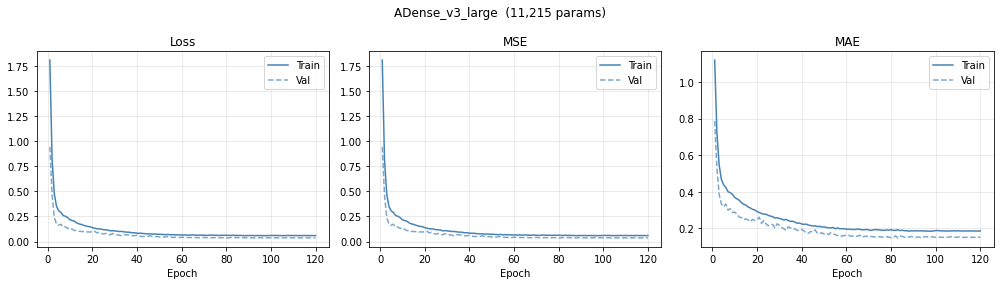

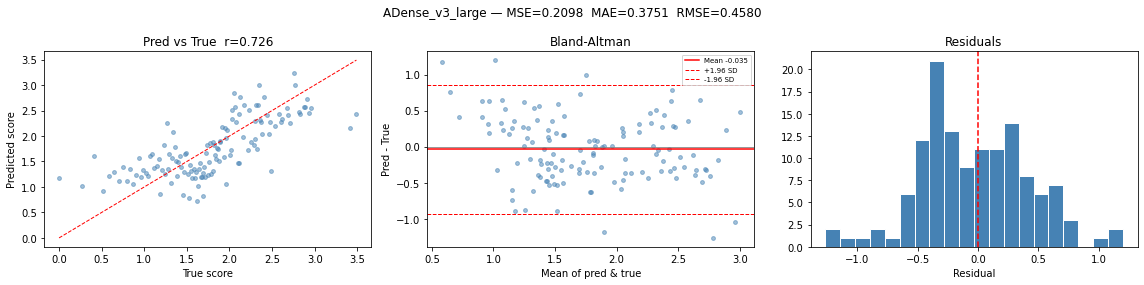

Comparing 0.37462928593158723 < 0.3746877580881119
New Best! 0.37462928593158723  0.3746877580881119. Updating models on DagsHub


2026/05/26 18:23:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 18:23:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Score_Regressor_A15_V2' already exists. Creating a new version of this model...
2026/05/26 18:23:38 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Score_Regressor_A15_V2, version 5
Created version '5' of model 'Score_Regressor_A15_V2'.


Registered ADense_v3_large -> @dev (v5)
🏃 View run A15 - ADense_v3_large at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/45f1b91b577c4a0f8ce854e6bd7aef69
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.3646  MAE=0.4970  RMSE=0.6039
  Fold  2 | MSE=0.1681  MAE=0.3552  RMSE=0.4100
  Fold  3 | MSE=0.1347  MAE=0.2490  RMSE=0.3670
  Fold  4 | MSE=0.2200  MAE=0.3903  RMSE=0.4691
  Fold  5 | MSE=0.3283  MAE=0.4263  RMSE=0.5729
  Fold  6 | MSE=0.3717  MAE=0.5418  RMSE=0.6097
  Fold  7 | MSE=0.3919  MAE=0.4592  RMSE=0.6260
  Fold  8 | MSE=0.0961  MAE=0.2717  RMSE=0.3101
  Fold  9 | MSE=0.2073  MAE=0.3454  RMSE=0.4553
  Fold 10 | MSE=0.1656  MAE=0.2905  RMSE=0.4070

--- ADense_v4_smallbatch (8,695 params) ---
10-fold: MSE=0.2448  MAE=0.3826  RMSE=0.4831


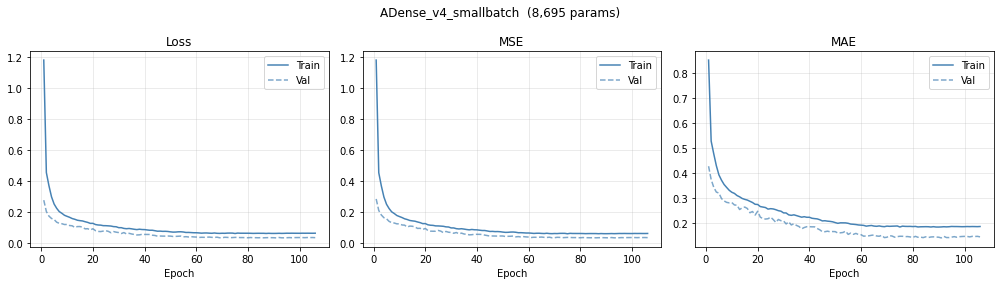

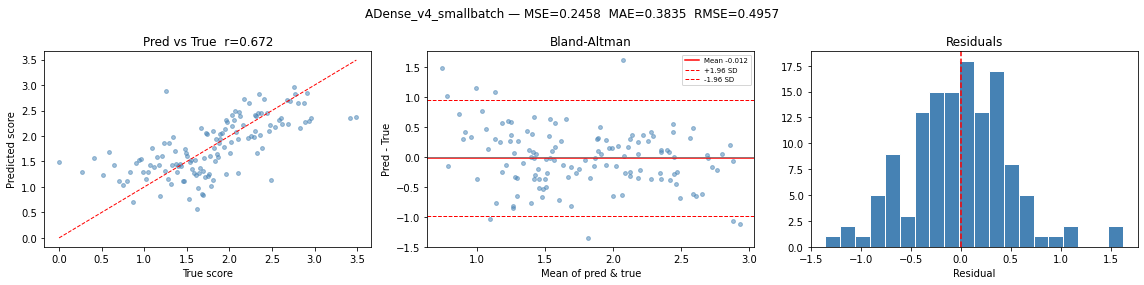

Comparing 0.3826495185494423 < 0.37462928593158723
  ADense_v4_smallbatch did not beat @dev
🏃 View run A15 - ADense_v4_smallbatch at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/09c8ffb7b2b04e42a14629eef920fbb6
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2814  MAE=0.4098  RMSE=0.5305
  Fold  2 | MSE=0.1370  MAE=0.2722  RMSE=0.3701
  Fold  3 | MSE=0.0988  MAE=0.2660  RMSE=0.3143
  Fold  4 | MSE=0.2807  MAE=0.4573  RMSE=0.5298
  Fold  5 | MSE=0.3751  MAE=0.4824  RMSE=0.6125
  Fold  6 | MSE=0.3003  MAE=0.4654  RMSE=0.5480
  Fold  7 | MSE=0.3397  MAE=0.4322  RMSE=0.5828
  Fold  8 | MSE=0.1071  MAE=0.3115  RMSE=0.3273
  Fold  9 | MSE=0.2071  MAE=0.3361  RMSE=0.4551
  Fold 10 | MSE=0.0678  MAE=0.2189  RMSE=0.2603

--- ADense_v5_noscale (8,695 params) ---
10-fold: MSE=0.2195  MAE=0.3652  RMSE=0.4531


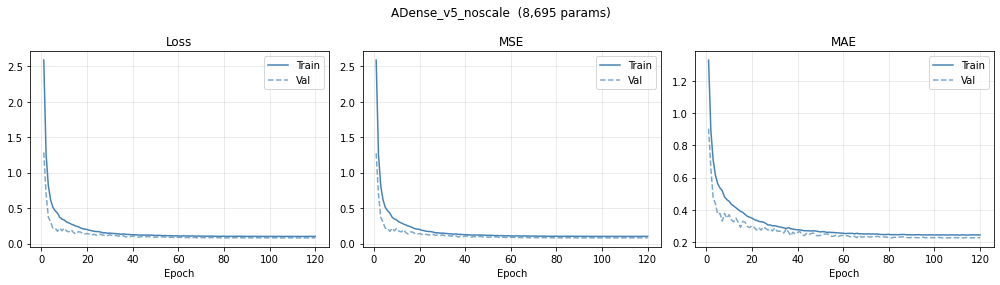

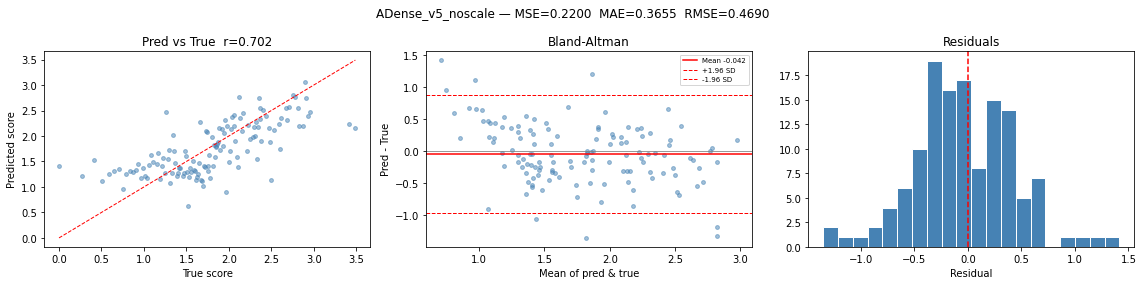

Comparing 0.36517920792102815 < 0.37462928593158723
New Best! 0.36517920792102815  0.37462928593158723. Updating models on DagsHub
Deleting old backup model.


2026/05/26 18:25:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 18:25:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Score_Regressor_A15_V2' already exists. Creating a new version of this model...
2026/05/26 18:25:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Score_Regressor_A15_V2, version 6
Created version '6' of model 'Score_Regressor_A15_V2'.


Registered ADense_v5_noscale -> @dev (v6)
🏃 View run A15 - ADense_v5_noscale at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/59871a67d2da4dcba2aa1858fdb74c70
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2452  MAE=0.3896  RMSE=0.4952
  Fold  2 | MSE=0.2254  MAE=0.3612  RMSE=0.4748
  Fold  3 | MSE=0.1351  MAE=0.2738  RMSE=0.3676
  Fold  4 | MSE=0.3058  MAE=0.4682  RMSE=0.5530
  Fold  5 | MSE=0.2490  MAE=0.3549  RMSE=0.4990
  Fold  6 | MSE=0.2982  MAE=0.4697  RMSE=0.5461
  Fold  7 | MSE=0.2924  MAE=0.4380  RMSE=0.5408
  Fold  8 | MSE=0.1146  MAE=0.2895  RMSE=0.3385
  Fold  9 | MSE=0.3328  MAE=0.3830  RMSE=0.5769
  Fold 10 | MSE=0.1042  MAE=0.2542  RMSE=0.3229

--- ACNN_v3_morefilters (4,257 params) ---
10-fold: MSE=0.2303  MAE=0.3682  RMSE=0.4715


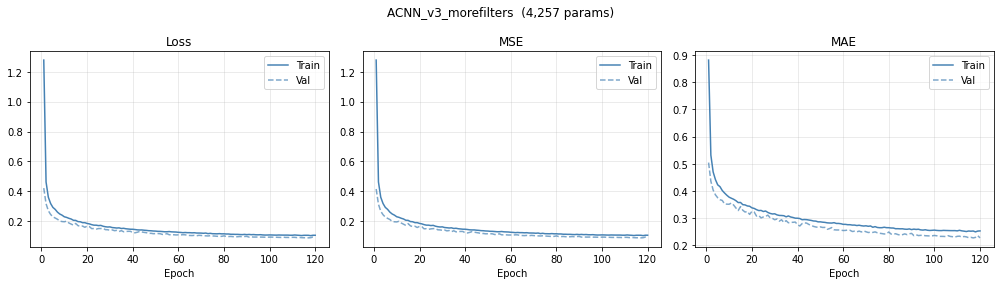

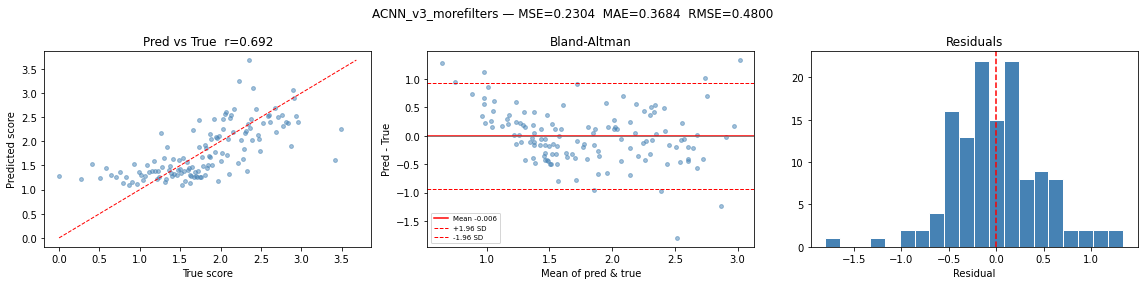

Comparing 0.36820835769176485 < 0.36517920792102815
  ACNN_v3_morefilters did not beat @dev
🏃 View run A15 - ACNN_v3_morefilters at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/ddc575bd148843a2aa16eaa92fd4a274
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2421  MAE=0.3938  RMSE=0.4921
  Fold  2 | MSE=0.2242  MAE=0.3718  RMSE=0.4735
  Fold  3 | MSE=0.0934  MAE=0.2434  RMSE=0.3056
  Fold  4 | MSE=0.2858  MAE=0.4728  RMSE=0.5346
  Fold  5 | MSE=0.1587  MAE=0.3145  RMSE=0.3983
  Fold  6 | MSE=0.3404  MAE=0.4961  RMSE=0.5835
  Fold  7 | MSE=0.2107  MAE=0.3842  RMSE=0.4590
  Fold  8 | MSE=0.1476  MAE=0.3481  RMSE=0.3842
  Fold  9 | MSE=0.1194  MAE=0.2836  RMSE=0.3456
  Fold 10 | MSE=0.0421  MAE=0.1783  RMSE=0.2053

--- ACNN_v4_nopool (1,073 params) ---
10-fold: MSE=0.1864  MAE=0.3487  RMSE=0.4182


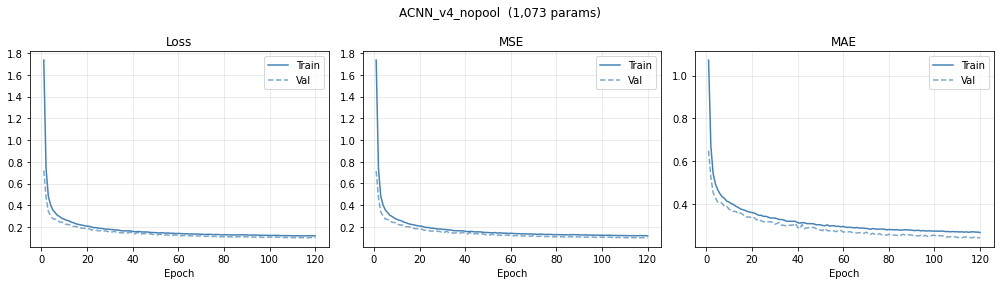

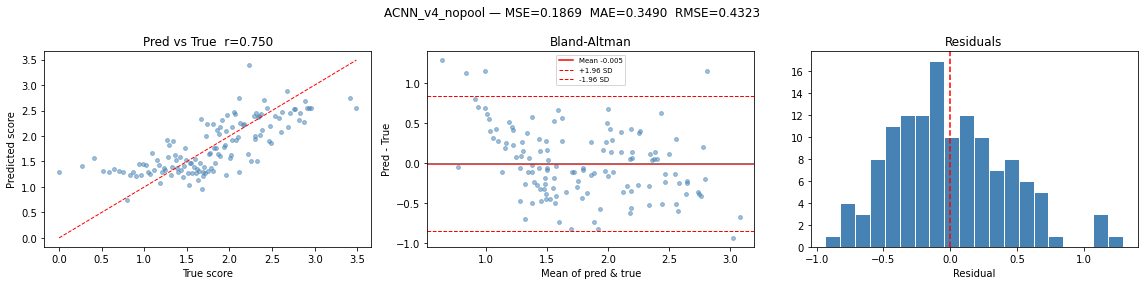

Comparing 0.34865920543670653 < 0.36517920792102815
New Best! 0.34865920543670653  0.36517920792102815. Updating models on DagsHub
Deleting old backup model.


2026/05/26 18:28:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 18:28:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'Score_Regressor_A15_V2' already exists. Creating a new version of this model...
2026/05/26 18:28:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Score_Regressor_A15_V2, version 7
Created version '7' of model 'Score_Regressor_A15_V2'.


Registered ACNN_v4_nopool -> @dev (v7)
🏃 View run A15 - ACNN_v4_nopool at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/5f74cc9a06fd441d84408d2df18dd322
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.3278  MAE=0.4231  RMSE=0.5725
  Fold  2 | MSE=0.2870  MAE=0.4198  RMSE=0.5357
  Fold  3 | MSE=0.1006  MAE=0.2029  RMSE=0.3171
  Fold  4 | MSE=0.3482  MAE=0.4660  RMSE=0.5901
  Fold  5 | MSE=0.3300  MAE=0.4541  RMSE=0.5745
  Fold  6 | MSE=0.3113  MAE=0.4570  RMSE=0.5579
  Fold  7 | MSE=0.2979  MAE=0.4163  RMSE=0.5458
  Fold  8 | MSE=0.1793  MAE=0.3525  RMSE=0.4235
  Fold  9 | MSE=0.3627  MAE=0.4716  RMSE=0.6023
  Fold 10 | MSE=0.0784  MAE=0.2365  RMSE=0.2801

--- ACNN_v5_smallkernel (1,169 params) ---
10-fold: MSE=0.2623  MAE=0.3900  RMSE=0.5000


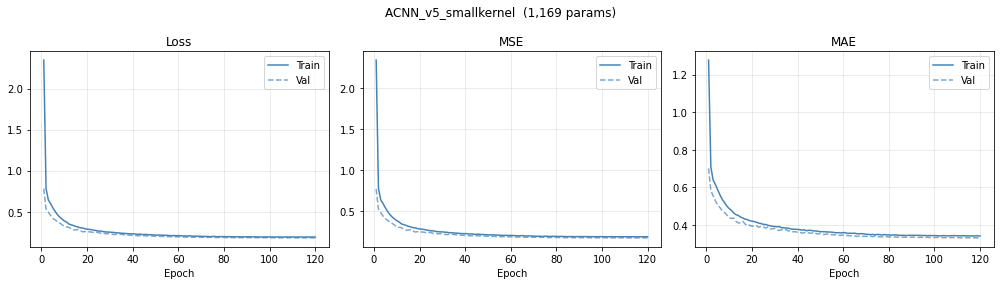

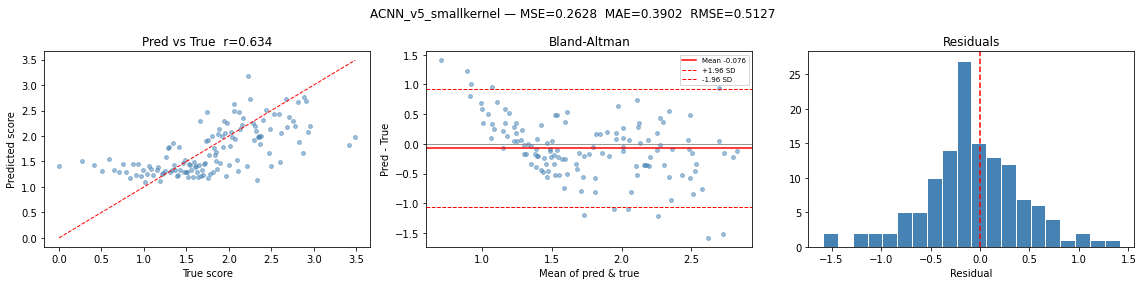

Comparing 0.38995295763015747 < 0.34865920543670653
  ACNN_v5_smallkernel did not beat @dev
🏃 View run A15 - ACNN_v5_smallkernel at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/5a9558e65ecc46908935abcded6fc7da
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.3458  MAE=0.4283  RMSE=0.5881
  Fold  2 | MSE=0.2694  MAE=0.4153  RMSE=0.5191
  Fold  3 | MSE=0.0999  MAE=0.2683  RMSE=0.3161
  Fold  4 | MSE=0.2921  MAE=0.4494  RMSE=0.5405
  Fold  5 | MSE=0.3640  MAE=0.4757  RMSE=0.6033
  Fold  6 | MSE=0.3625  MAE=0.4871  RMSE=0.6020
  Fold  7 | MSE=0.2965  MAE=0.3818  RMSE=0.5445
  Fold  8 | MSE=0.1296  MAE=0.3270  RMSE=0.3601
  Fold  9 | MSE=0.5628  MAE=0.4388  RMSE=0.7502
  Fold 10 | MSE=0.1148  MAE=0.2501  RMSE=0.3388

--- ARNN_GRU_v2_deep (15,489 params) ---
10-fold: MSE=0.2838  MAE=0.3922  RMSE=0.5163


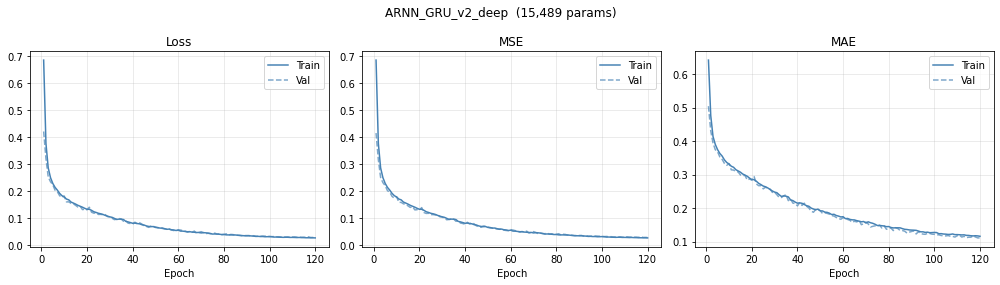

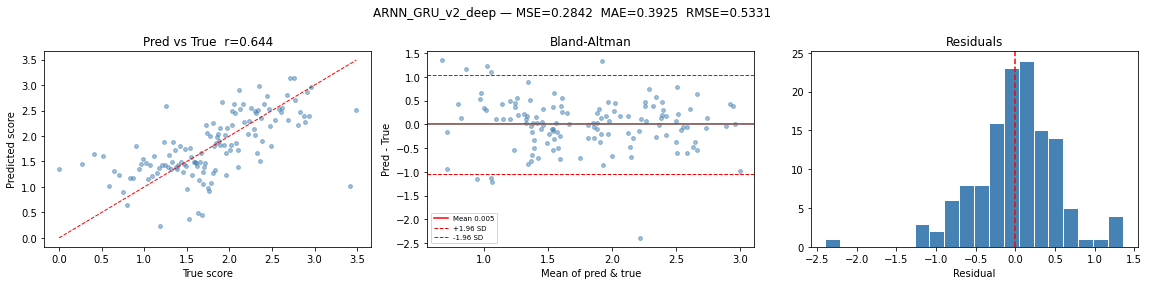

Comparing 0.39219034612178805 < 0.34865920543670653
  ARNN_GRU_v2_deep did not beat @dev
🏃 View run A15 - ARNN_GRU_v2_deep at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/973eacbb5bdd4a4bb0cdc315573c9e43
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.2876  MAE=0.4786  RMSE=0.5363
  Fold  2 | MSE=0.1560  MAE=0.3387  RMSE=0.3950
  Fold  3 | MSE=0.1567  MAE=0.2955  RMSE=0.3959
  Fold  4 | MSE=0.2238  MAE=0.3842  RMSE=0.4730
  Fold  5 | MSE=0.2539  MAE=0.3572  RMSE=0.5039
  Fold  6 | MSE=0.3583  MAE=0.4810  RMSE=0.5986
  Fold  7 | MSE=0.1630  MAE=0.3076  RMSE=0.4037
  Fold  8 | MSE=0.1380  MAE=0.3135  RMSE=0.3715
  Fold  9 | MSE=0.1164  MAE=0.3104  RMSE=0.3412
  Fold 10 | MSE=0.1440  MAE=0.2958  RMSE=0.3795

--- ARNN_LSTM_v2_deep (20,641 params) ---
10-fold: MSE=0.1998  MAE=0.3563  RMSE=0.4399


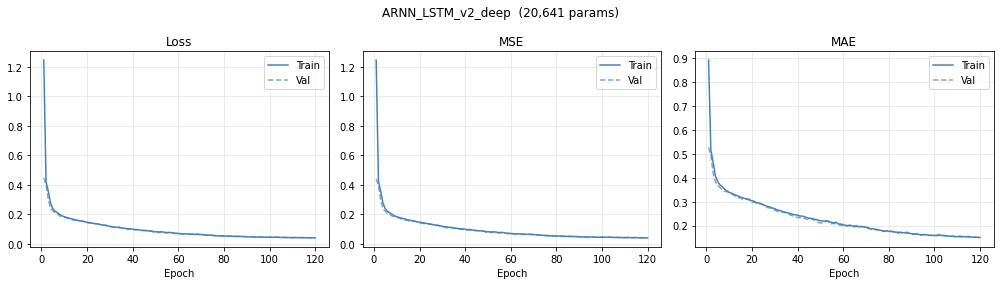

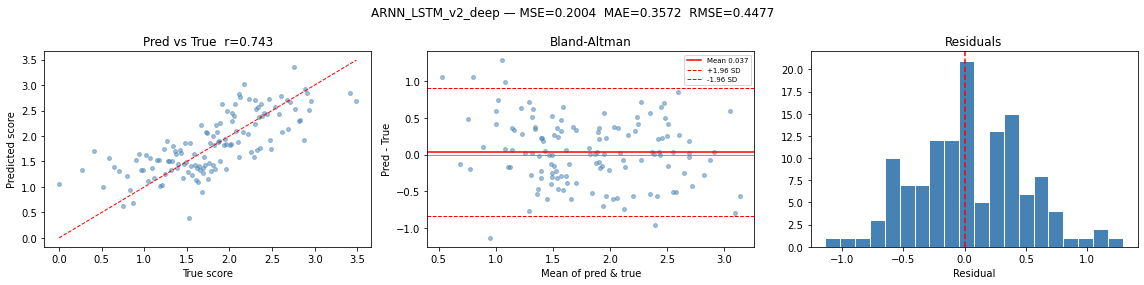

Comparing 0.3562577456235886 < 0.34865920543670653
  ARNN_LSTM_v2_deep did not beat @dev
🏃 View run A15 - ARNN_LSTM_v2_deep at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/f70abb68867846ef9ab406d13969d9f6
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.3811  MAE=0.5291  RMSE=0.6173
  Fold  2 | MSE=0.1926  MAE=0.3673  RMSE=0.4389
  Fold  3 | MSE=0.1774  MAE=0.3317  RMSE=0.4212
  Fold  4 | MSE=0.2736  MAE=0.4733  RMSE=0.5231
  Fold  5 | MSE=0.5625  MAE=0.5666  RMSE=0.7500
  Fold  6 | MSE=0.2734  MAE=0.4507  RMSE=0.5229
  Fold  7 | MSE=0.2470  MAE=0.4045  RMSE=0.4970
  Fold  8 | MSE=0.3003  MAE=0.4706  RMSE=0.5480
  Fold  9 | MSE=0.2548  MAE=0.3553  RMSE=0.5047
  Fold 10 | MSE=0.0914  MAE=0.2501  RMSE=0.3024

--- ARNN_GRU_v3_smallhidden (3,809 params) ---
10-fold: MSE=0.2754  MAE=0.4199  RMSE=0.5125


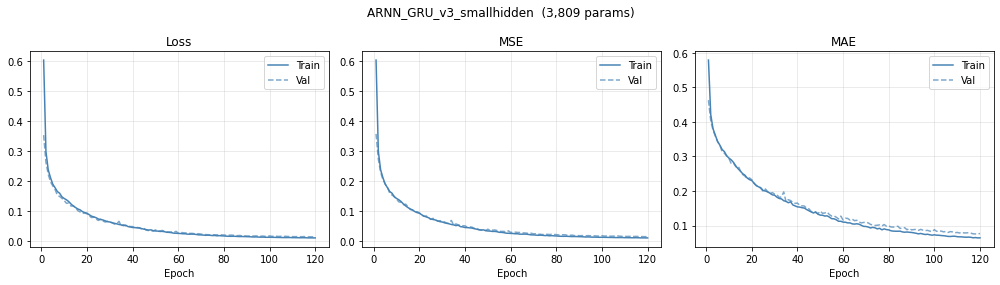

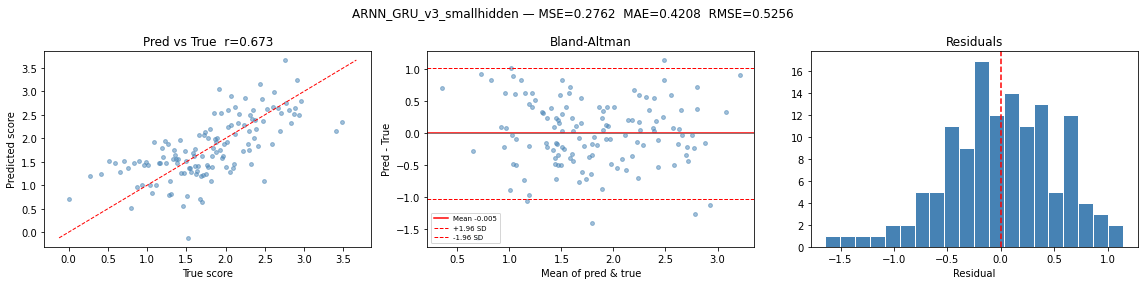

Comparing 0.4199261605739594 < 0.34865920543670653
  ARNN_GRU_v3_smallhidden did not beat @dev
🏃 View run A15 - ARNN_GRU_v3_smallhidden at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/4f25346b8b314eaf8c82228e07e02162
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
  Fold  1 | MSE=0.4001  MAE=0.4958  RMSE=0.6325
  Fold  2 | MSE=0.1811  MAE=0.3756  RMSE=0.4256
  Fold  3 | MSE=0.1755  MAE=0.2962  RMSE=0.4190
  Fold  4 | MSE=0.1733  MAE=0.3348  RMSE=0.4163
  Fold  5 | MSE=0.3029  MAE=0.4039  RMSE=0.5503
  Fold  6 | MSE=0.3456  MAE=0.5299  RMSE=0.5878
  Fold  7 | MSE=0.2158  MAE=0.3812  RMSE=0.4645
  Fold  8 | MSE=0.1151  MAE=0.2823  RMSE=0.3393
  Fold  9 | MSE=0.0740  MAE=0.2424  RMSE=0.2721
  Fold 10 | MSE=0.1966  MAE=0.3477  RMSE=0.4434

--- ARNN_LSTM_v3_largebatch (12,193 params) ---
10-fold: MSE=0.2180  MAE=0.3690  RMSE=0.4551


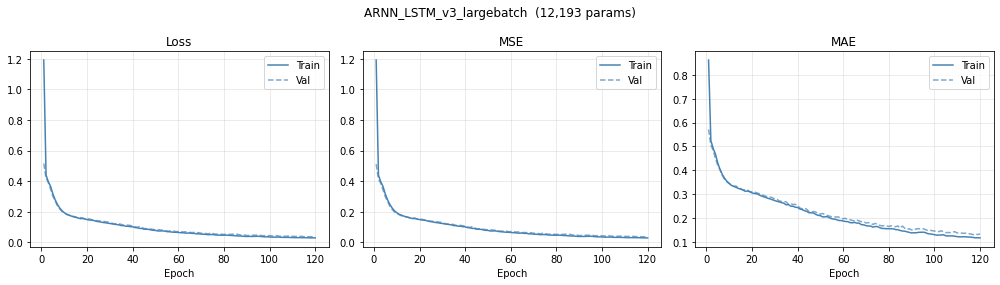

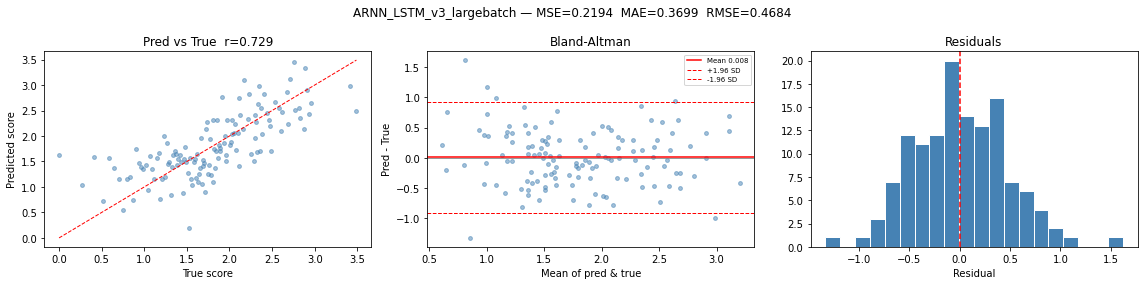

Comparing 0.3689803838729858 < 0.34865920543670653
  ARNN_LSTM_v3_largebatch did not beat @dev
🏃 View run A15 - ARNN_LSTM_v3_largebatch at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/8572dde397cb4da59034f75561d9a081
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0


In [13]:
def build_model(config):
    mt=config['model_type']
    if mt=='dense': return ADense(INPUT_DENSE,config['h1'],config['h2'],config['dropout'])
    if mt=='cnn':   return ACNN(N_FEAT,C,config['n_filters'],config['kernel_size'],
                                config['pool_size'],config['fc_h'],config['dropout'])
    return ARNN(N_FEAT,config['hidden'],config['num_layers'],config['rnn_type'],config['dropout'])

def get_X(config, indices):
    return X_flat[indices] if config['model_type']=='dense' else X_seq[indices]


all_variant_results = []

for config in ALL_VARIANTS:
    set_seed(SEED)
    note        = config['note']
    ckpt_path   = f'best_{note}.pth'
    scaler_path = f'scaler_{note}.joblib'
    for p in (ckpt_path, scaler_path):
        if os.path.exists(p): os.remove(p)

    _demo    = build_model(config)
    n_params = count_params(_demo); del _demo

    gkf         = GroupKFold(n_splits=N_FOLDS)
    orig_groups = grp_all[orig_indices]
    orig_y      = y_all[orig_indices]

    with mlflow.start_run(run_name=f'A15 - {note}') as run:
        log_cfg = {k:v for k,v in config.items()}
        log_cfg.update({'c_frames':C,'n_features':N_FEAT,'input_dim':INPUT_DENSE,'n_params':n_params})
        mlflow.log_params(log_cfg)

        fold_results=[]; fold_histories=[]
        agg_preds=[]; agg_targets=[]
        best_overall_mse=float('inf')

        for fold,(tr_orig,te_orig) in enumerate(gkf.split(orig_indices,orig_y,orig_groups)):
            train_groups=set(orig_groups[tr_orig])
            test_groups =set(orig_groups[te_orig])

            train_mask=np.array([g in train_groups for g in grp_all])
            orig_set  =set(orig_indices.tolist())
            test_mask =np.array([idx in orig_set and grp_all[idx] in test_groups
                                  for idx in range(len(grp_all))])

            X_tr_raw=get_X(config,np.where(train_mask)[0]); y_tr=y_all[train_mask]
            X_te_raw=get_X(config,np.where(test_mask)[0]);  y_te=y_all[test_mask]

            scaler=None
            if config.get('use_scaling'):
                scaler=MinMaxScaler()
                flat_tr=X_tr_raw.reshape(len(X_tr_raw),-1)
                scaler.fit(flat_tr)
                X_tr_s=scaler.transform(flat_tr).reshape(X_tr_raw.shape)
                X_te_s=scaler.transform(X_te_raw.reshape(len(X_te_raw),-1)).reshape(X_te_raw.shape)
            else:
                X_tr_s,X_te_s=X_tr_raw,X_te_raw

            shuf=np.random.permutation(len(X_tr_s))
            X_tr_s=X_tr_s[shuf]; y_tr=y_tr[shuf]
            val_split=int(len(X_tr_s)*0.9)
            X_t,X_v=X_tr_s[:val_split],X_tr_s[val_split:]
            y_t,y_v=y_tr[:val_split],y_tr[val_split:]

            train_loader=DataLoader(ScoreDataset(X_t,y_t),batch_size=config['batch_size'],
                                    shuffle=True,drop_last=True)
            val_loader  =DataLoader(ScoreDataset(X_v,y_v),batch_size=config['batch_size'],shuffle=False)
            test_loader =DataLoader(ScoreDataset(X_te_s,y_te),batch_size=config['batch_size'],shuffle=False)

            model    =build_model(config).to(device)
            optimizer=optim.Adam(model.parameters(),lr=config['lr'])
            scheduler=ReduceLROnPlateau(optimizer,'min',factor=0.5,patience=5,min_lr=1e-6)
            criterion=nn.MSELoss()

            best_vl,patience_ctr=float('inf'),0
            fold_ckpt=f'fold_{fold}_{note}.pth'
            history={k:[] for k in ['tl','vl','tm','vm','ta','va']}

            for epoch in range(config['epochs']):
                tl,tm,ta=run_epoch(model,train_loader,optimizer,criterion,device,True)
                vl,vm,va=run_epoch(model,val_loader,optimizer,criterion,device,False)
                scheduler.step(vl)
                for k,v in zip(['tl','vl','tm','vm','ta','va'],[tl,vl,tm,vm,ta,va]):
                    history[k].append(v)
                if vl<best_vl:
                    best_vl,patience_ctr=vl,0
                    torch.save(model.state_dict(),fold_ckpt)
                else:
                    patience_ctr+=1
                    if patience_ctr>=config['patience']: break

            fold_histories.append(history)
            model.load_state_dict(torch.load(fold_ckpt,weights_only=True))
            m=evaluate(model,test_loader,device)
            m['fold']=fold+1
            fold_results.append(m)
            agg_preds.extend(m['preds'].tolist())
            agg_targets.extend(m['targets'].tolist())

            print(f'  Fold {fold+1:2d} | MSE={m["MSE"]:.4f}  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}')

            if m['MSE']<best_overall_mse:
                best_overall_mse=m['MSE']
                torch.save(model.state_dict(),ckpt_path)
                if scaler is not None: joblib.dump(scaler,scaler_path)

            if os.path.exists(fold_ckpt): os.remove(fold_ckpt)

        avg_mse =float(np.mean([r['MSE']  for r in fold_results]))
        avg_mae =float(np.mean([r['MAE']  for r in fold_results]))
        avg_rmse=float(np.mean([r['RMSE'] for r in fold_results]))

        mlflow.log_metric('mean_MSE',  avg_mse)
        mlflow.log_metric('mean_MAE',  avg_mae)
        mlflow.log_metric('mean_RMSE', avg_rmse)
        mlflow.log_metric('n_params',  n_params)

        print(f'\n--- {note} ({n_params:,} params) ---')
        print(f'10-fold: MSE={avg_mse:.4f}  MAE={avg_mae:.4f}  RMSE={avg_rmse:.4f}')

        curves_path=plot_curves(fold_histories,note,n_params)
        mlflow.log_artifact(curves_path)

        agg_p=np.array(agg_preds); agg_t=np.array(agg_targets)
        agg_metrics={'MSE':float(np.mean((agg_p-agg_t)**2)),
                     'MAE':float(np.mean(np.abs(agg_p-agg_t))),
                     'RMSE':float(np.sqrt(np.mean((agg_p-agg_t)**2)))}
        eval_path=plot_evaluation(agg_p,agg_t,note,agg_metrics)
        mlflow.log_artifact(eval_path)

        r,_=pearsonr(agg_t,agg_p)
        mlflow.log_metric('pearson_r',float(r))

        rpt=pd.DataFrame([{'fold':r['fold'],'MSE':r['MSE'],'MAE':r['MAE'],'RMSE':r['RMSE']}
                           for r in fold_results])
        rpt_path=f'fold_results_{note}.csv'
        rpt.to_csv(rpt_path,index=False)
        mlflow.log_artifact(rpt_path)

        all_variant_results.append({'note':note,'model_type':config['model_type'],
            'n_params':n_params,'MSE':avg_mse,'MAE':avg_mae,'RMSE':avg_rmse,'r':float(r)})

        if utils.auto_check_challenger(run.info.run_id,metric_name='mean_MAE') \
                and os.path.exists(ckpt_path):
            m_log=build_model(config).to(device)
            m_log.load_state_dict(torch.load(ckpt_path,map_location=device,weights_only=True))
            mlflow.pytorch.log_model(m_log,'model',registered_model_name=PROJECT)
            if os.path.exists(scaler_path): mlflow.log_artifact(scaler_path)
            latest_v=utils.client.get_latest_versions(PROJECT)[0].version
            utils.client.set_registered_model_alias(PROJECT,'dev',latest_v)
            print(f'Registered {note} -> @dev (v{latest_v})')
        else:
            print(f'  {note} did not beat @dev')

        for p in (ckpt_path,scaler_path):
            if os.path.exists(p): os.remove(p)


## Summary

                   note model_type  n_params    MSE    MAE   RMSE      r
         ACNN_v4_nopool        cnn      1073 0.1864 0.3487 0.4182 0.7497
      ARNN_LSTM_v2_deep        rnn     20641 0.1998 0.3563 0.4399 0.7433
        ADense_v3_large      dense     11215 0.2094 0.3746 0.4529 0.7264
ARNN_LSTM_v3_largebatch        rnn     12193 0.2180 0.3690 0.4551 0.7290
      ADense_v5_noscale      dense      8695 0.2195 0.3652 0.4531 0.7020
    ACNN_v3_morefilters        cnn      4257 0.2303 0.3682 0.4715 0.6922
   ADense_v4_smallbatch      dense      8695 0.2448 0.3826 0.4831 0.6722
    ACNN_v5_smallkernel        cnn      1169 0.2623 0.3900 0.5000 0.6337
ARNN_GRU_v3_smallhidden        rnn      3809 0.2754 0.4199 0.5125 0.6726
       ARNN_GRU_v2_deep        rnn     15489 0.2838 0.3922 0.5163 0.6442


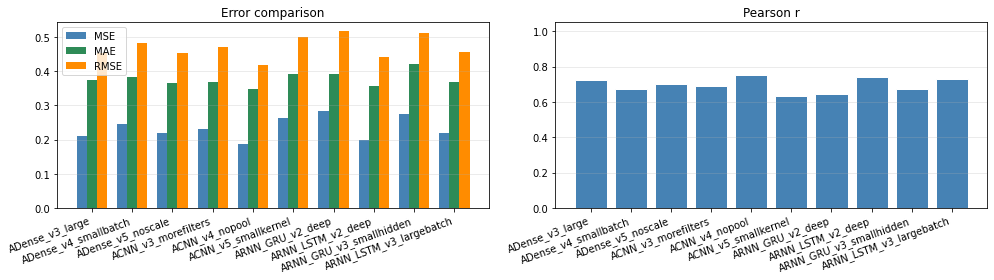

In [14]:
summary=pd.DataFrame(all_variant_results)[['note','model_type','n_params','MSE','MAE','RMSE','r']]
summary=summary.sort_values('MSE').reset_index(drop=True)
print(summary.to_string(index=False,float_format='{:.4f}'.format))
summary.to_csv(os.path.join(PLOTS_DIR,'summary.csv'),index=False)

fig,axes=plt.subplots(1,2,figsize=(14,4))
notes=[r['note'] for r in all_variant_results]
x=np.arange(len(notes)); w=0.25
axes[0].bar(x-w,[r['MSE'] for r in all_variant_results],w,label='MSE',color='steelblue')
axes[0].bar(x,  [r['MAE'] for r in all_variant_results],w,label='MAE',color='seagreen')
axes[0].bar(x+w,[r['RMSE'] for r in all_variant_results],w,label='RMSE',color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(notes,rotation=20,ha='right')
axes[0].set_title('Error comparison'); axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)

axes[1].bar(x,[r['r'] for r in all_variant_results],color='steelblue',edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(notes,rotation=20,ha='right')
axes[1].set_ylim(0,1.05); axes[1].set_title('Pearson r'); axes[1].grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,'comparison.png'),dpi=120); plt.show()


## Inference

In [21]:
def load_prod(project, device):
    client  = mlflow.MlflowClient()
    version = client.get_model_version_by_alias(project,'prod')
    run     = client.get_run(version.run_id)
    model   = mlflow.pytorch.load_model(f'models:/{project}@prod',map_location=device).to(device)
    model.eval()
    scaler=None
    try:
        arts=[a.path for a in client.list_artifacts(version.run_id) if a.path.startswith('scaler_')]
        if arts:
            scaler=joblib.load(client.download_artifacts(version.run_id,arts[0]))
    except: pass
    mt=run.data.params.get('model_type','dense')
    print(f'Loaded @prod: {run.data.params.get("note")}  type={mt}')
    return model,scaler,mt


def predict_score(filepath, model, scaler, model_type, device,
                   feat_cols=FEAT_COLS):
    df     = pd.read_csv(filepath)
    cut_df = cut_with_model(df, ss_model, SS_CONFIG, device)
    if cut_df is None:
        return None
    arr      = cut_df[feat_cols].values.astype('float32')
    enriched = add_features(arr, feat_cols)
    fixed    = to_fixed_length(enriched, C)
    print(enriched.size/ 61)
    X = fixed.flatten()[None,:] if model_type=='dense' else fixed[None,:,:]
    if scaler is not None:
        X=scaler.transform(X.reshape(1,-1)).reshape(X.shape)
    model.eval()
    with torch.no_grad():
        score=model(torch.tensor(X,dtype=torch.float32,device=device)).item()
    return float(np.clip(score,0,SCORE_MAX))


reg_model, reg_scaler, reg_type = load_prod(PROJECT, device)

TEST_FILE = all_csv[143]
key       = os.path.splitext(os.path.basename(TEST_FILE))[0].replace('_kinect','')
pred      = predict_score(TEST_FILE, reg_model, reg_scaler, reg_type, device)
gt        = scores_map.get(key,'N/A')

print(f'File      : {os.path.basename(TEST_FILE)}')
print(f'Predicted : {pred:.4f}')
print(f'GT score  : {gt}')


Loaded @prod: ACNN_v4_nopool  type=cnn
261.0
File      : A87_kinect.csv
Predicted : 2.4442
GT score  : 2.738998538856615



![MAE of Experiments](img/image.png)

![Plots of champion](img/eval_ACNN_v4_nopool.png)

![Plots of champion](img/curves_ACNN_v4_nopool.png)


## Config of champion

batch_size: 32
c_frames: 10
dropout: 0.2
epochs: 120
fc_h: 8
input_dim: 610
kernel_size: 3
lr: 0.001
model_type: cnn
n_features: 61
n_filters: 4
n_params: 1073
patience: 15
pool_size: 1
use_scaling: True


## Results of champion

MAE: 0.34865920543670653

MSE: 0.18644575104117395

n_params: 1073

pearson_r: 0.7496543690111279